<a href="https://colab.research.google.com/github/Renyambar/Reny_MachineLearning/blob/main/JS04/JS04_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Membaca dataset
data = pd.read_csv('insurance.csv')

# Menampilkan 5 data pertama
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Deskripsi Dataset

Dataset **Medical Cost Personal Datasets** berisi data biaya asuransi kesehatan individu di Amerika Serikat, dengan **1338 baris** dan **7 kolom**:

| Kolom | Keterangan |
|---|---|
| `age` | Usia pemegang polis (tahun) |
| `sex` | Jenis kelamin (`female` / `male`) |
| `bmi` | Body Mass Index (indeks massa tubuh) |
| `children` | Jumlah anak/tanggungan yang dicover asuransi |
| `smoker` | Status merokok (`yes` / `no`) |
| `region` | Wilayah tempat tinggal di AS (`northeast`, `northwest`, `southeast`, `southwest`) |
| `charges` | Biaya medis personal yang ditagihkan (variabel **target**) |

**Variabel bebas (fitur):** `age`, `sex`, `bmi`, `children`, `smoker`, `region`
**Variabel target:** `charges`

##TUGAS


### Langkah 1 - Identifikasi variabel-variabel yang akan digunakan sebagai variabel bebas (fitur) dan variabel target (biaya medis personal).

Jumlah data: (1338, 7)

Kolom dataset:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Statistik dataset:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


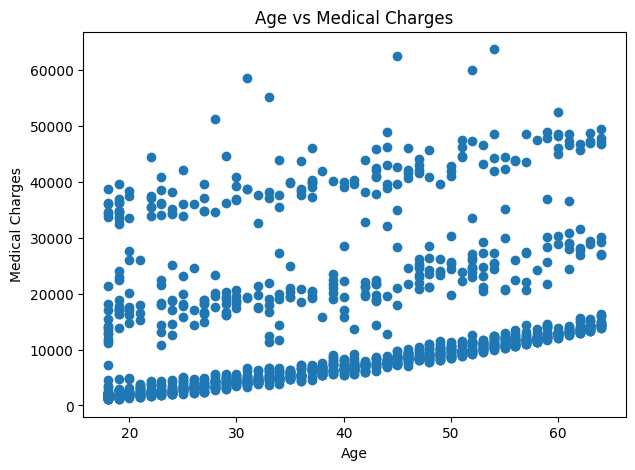

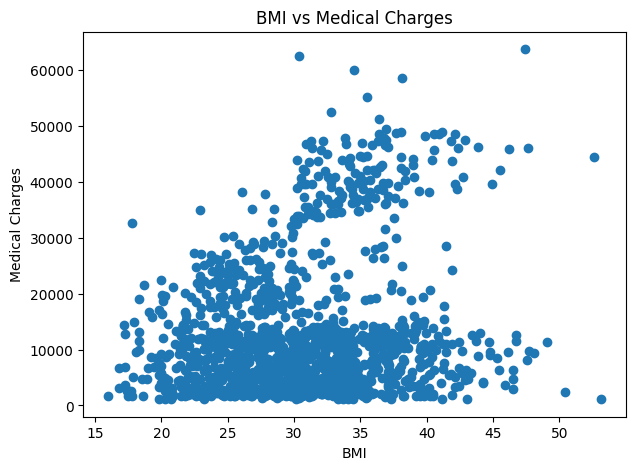

In [6]:
# Melihat informasi dataset
print("Jumlah data:", data.shape)
print("\nKolom dataset:")
print(data.columns)

print("\nStatistik dataset:")
display(data.describe())


# Visualisasi Age vs Charges
plt.figure(figsize=(7, 5))
plt.scatter(data['age'], data['charges'])

plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.title('Age vs Medical Charges')

plt.show()


# Visualisasi BMI vs Charges
plt.figure(figsize=(7, 5))
plt.scatter(data['bmi'], data['charges'])

plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.title('BMI vs Medical Charges')

plt.show()

###Langkah 2 - Bagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi yang sesuai.

In [7]:
# Mengubah data kategori menjadi angka
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'])

# Menentukan fitur dan target
X = data.drop('charges', axis=1)
y = data['charges']

# Membagi data menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Jumlah data training:", X_train.shape)
print("Jumlah data testing :", X_test.shape)

Jumlah data training: (1070, 11)
Jumlah data testing : (268, 11)


###Langkah 3 - Lakukan feature scaling jika diperlukan.

In [8]:
# Melakukan scaling untuk kebutuhan SVR
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling berhasil dilakukan.")

Scaling berhasil dilakukan.


###Langkah 4 - Buat model multiple linear regression menggunakan Scikit-Learn.

In [9]:
# Membuat model Multiple Linear Regression
model_lr = LinearRegression()

# Melatih model
model_lr.fit(X_train, y_train)

# Melakukan prediksi
y_pred_lr = model_lr.predict(X_test)

# Evaluasi model
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=== Multiple Linear Regression ===")
print("R-squared :", r2_lr)
print("MSE       :", mse_lr)
print("MAE       :", mae_lr)

=== Multiple Linear Regression ===
R-squared : 0.7835929767120722
MSE       : 33596915.85136148
MAE       : 4181.194473753647


###Langkah 5 - Latih model pada data latih dan lakukan prediksi pada data uji.

,Actual,Predicted
0,9095.06825,8969.550274
1,5272.17580,7068.747443
2,29330.98315,36858.410912
3,9301.89355,9454.678501
4,33750.29180,26973.173457
5,4536.25900,10864.113164
6,2117.33885,170.280841
7,14210.53595,16903.450287
8,3732.62510,1092.430936
9,10264.44210,11218.343184


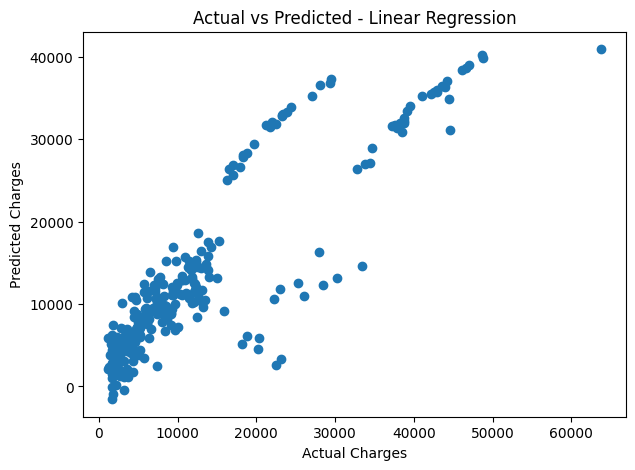

In [10]:
# Menampilkan beberapa hasil prediksi
hasil_prediksi = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_lr[:10]
})

display(hasil_prediksi)

# Visualisasi Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted - Linear Regression')

plt.show()

 ### Langkah 6 - Evaluasi model dengan menghitung metrik seperti R-squared, MSE, dan MAE. Tampilkan hasil evaluasi.

In [11]:
# Membuat model SVR
model_svr = SVR()

# Melatih model menggunakan data yang sudah di-scaling
model_svr.fit(X_train_scaled, y_train)

# Prediksi
y_pred_svr = model_svr.predict(X_test_scaled)

# Evaluasi SVR
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("=== SVR ===")
print("R-squared :", r2_svr)
print("MSE       :", mse_svr)
print("MAE       :", mae_svr)

=== SVR ===
R-squared : -0.06894401159271046
MSE       : 165952201.83549592
MAE       : 8611.415551847522


###Langkah 7 - Ulangi langkah 4 dengan menggunakan model SVR. Anda dapat bereksperimen dengan dengan melakukan hyperparameter tunning.

=== SVR Setelah Tuning ===
Parameter terbaik: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
R-squared : 0.3351431563673357
MSE       : 103218181.59759553
MAE       : 5698.833684697735

=== Perbandingan Model ===


,Model,R-squared,MSE,MAE
0,Multiple Linear Regression,0.783593,3.359692e+07,4181.194474
1,SVR,-0.068944,1.659522e+08,8611.415552
2,SVR Tuning,0.335143,1.032182e+08,5698.833685


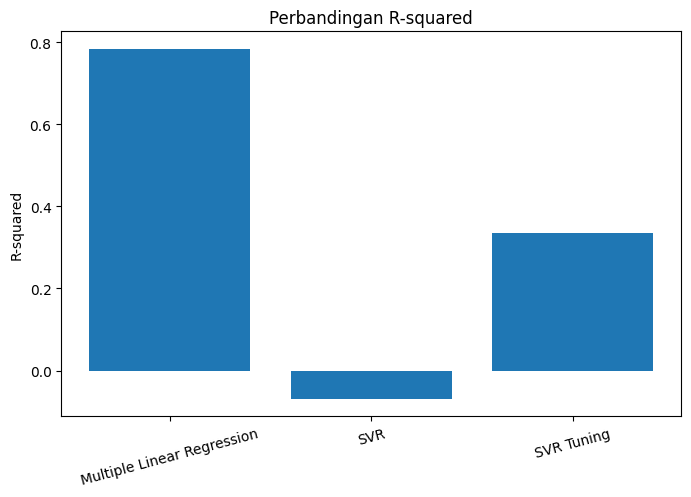

In [12]:
# Parameter yang akan dicoba
parameter = {
    'C': [1, 10, 100],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf']
}

# Hyperparameter tuning
grid = GridSearchCV(
    SVR(),
    parameter,
    cv=5
)

grid.fit(X_train_scaled, y_train)

# Prediksi menggunakan model terbaik
y_pred_tuning = grid.predict(X_test_scaled)

# Evaluasi
r2_tuning = r2_score(y_test, y_pred_tuning)
mse_tuning = mean_squared_error(y_test, y_pred_tuning)
mae_tuning = mean_absolute_error(y_test, y_pred_tuning)

print("=== SVR Setelah Tuning ===")
print("Parameter terbaik:", grid.best_params_)
print("R-squared :", r2_tuning)
print("MSE       :", mse_tuning)
print("MAE       :", mae_tuning)

# Perbandingan semua model
hasil = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR', 'SVR Tuning'],
    'R-squared': [r2_lr, r2_svr, r2_tuning],
    'MSE': [mse_lr, mse_svr, mse_tuning],
    'MAE': [mae_lr, mae_svr, mae_tuning]
})

print("\n=== Perbandingan Model ===")
display(hasil)

# Visualisasi R-squared
plt.figure(figsize=(8, 5))
plt.bar(hasil['Model'], hasil['R-squared'])

plt.ylabel('R-squared')
plt.title('Perbandingan R-squared')

plt.xticks(rotation=15)
plt.show()

## 1. Multiple Linear Regression

Model **Multiple Linear Regression** memperoleh:

-   **R-squared = 0,783593**
-   **MSE = 33.596.920**
-   **MAE = 4.181,19**

Nilai R-squared sebesar **0,78** menunjukkan bahwa model dapat
menjelaskan sekitar **78,36% variasi biaya medis** berdasarkan fitur
yang digunakan.

Nilai MAE sebesar **4.181,19** berarti secara rata-rata hasil prediksi
model memiliki selisih sekitar **4.181** dari biaya medis sebenarnya.

Dari grafik perbandingan, nilai R-squared model ini juga terlihat paling
tinggi dibandingkan dua model SVR.

## 2. SVR

Model SVR sebelum tuning menghasilkan:

-   **R-squared = -0,068944**
-   **MSE = 165.952.200**
-   **MAE = 8.611,42**

Hasil ini menunjukkan bahwa SVR standar belum mampu memprediksi biaya
medis dengan baik pada dataset ini.

Nilai **R-squared yang negatif** menunjukkan bahwa performa prediksi
model lebih buruk dibandingkan pendekatan sederhana yang menggunakan
rata-rata nilai target sebagai prediksi.

Selain itu, MAE sebesar **8.611,42** berarti rata-rata kesalahan
prediksi sekitar **8.611**. Nilai ini lebih besar dibandingkan Multiple
Linear Regression.

## 3. SVR Setelah Hyperparameter Tuning

Setelah dilakukan tuning, parameter terbaik yang diperoleh adalah:

``` text
C = 100
gamma = scale
kernel = rbf
```

Hasilnya:

-   **R-squared = 0,335143**
-   **MSE = 103.218.200**
-   **MAE = 5.698,83**

Terjadi peningkatan dibandingkan SVR sebelum tuning.

R-squared meningkat dari:

``` text
-0,068944 → 0,335143
```

MAE juga turun dari:

``` text
8.611,42 → 5.698,83
```

Artinya, **hyperparameter tuning berhasil meningkatkan performa SVR**
dibandingkan SVR dengan parameter default.

Namun, hasil SVR setelah tuning masih memiliki R-squared yang lebih
rendah dan MAE yang lebih tinggi dibandingkan Multiple Linear Regression
pada pengujian ini.

## Kesimpulan

> Berdasarkan hasil pengujian, Multiple Linear Regression dapat
> digunakan untuk memprediksi biaya medis dengan cukup baik pada dataset
> ini. Model tersebut memperoleh R-squared sebesar 0,783593, yang
> berarti sekitar 78,36% variasi biaya medis dapat dijelaskan oleh fitur
> yang digunakan. SVR tanpa tuning menghasilkan performa yang kurang
> baik, tetapi setelah dilakukan hyperparameter tuning, performanya
> mengalami peningkatan. Meskipun demikian, pada percobaan ini hasil SVR
> tuning masih belum mencapai performa Multiple Linear Regression. Hal
> ini menunjukkan bahwa pemilihan model dan parameter sangat berpengaruh
> terhadap hasil prediksi.
